In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import shap
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
import joblib

In [2]:
# 1. Data Ingestion
file_path = 'niazi and momand - kaggle dengue - Dengue Fever Hematological Dataset.csv'
if not os.path.exists(file_path):
    print(f"Error: {file_path} not found.")
    exit()

In [3]:
df = pd.read_csv(file_path)
print("Dataset Loaded.")

Dataset Loaded.


In [4]:
# 2. Preprocessing
if 'Gender' in df.columns:
    df['Gender'] = df['Gender'].replace({'Male': 0, 'Female': 1, 'male': 0, 'female': 1})

C:\Users\Sany\AppData\Local\Temp\ipykernel_5732\3303031706.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Gender'] = df['Gender'].replace({'Male': 0, 'Female': 1, 'male': 0, 'female': 1})


In [5]:
target_col = 'Result' if 'Result' in df.columns else df.columns[-1]
df['Target'] = df[target_col].replace({'negative': 0, 'positive': 1})

C:\Users\Sany\AppData\Local\Temp\ipykernel_5732\1428517213.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Target'] = df[target_col].replace({'negative': 0, 'positive': 1})


In [6]:
# Define features explicitly based on methodology and dataset
features = ['Age', 'Gender', 'Hemoglobin(g/dl)', 'Total Platelet Count(/cumm)', 'HCT(%)', 'WBC']
features = [f for f in features if f in df.columns]

In [7]:
# Median Imputation
X = df[features].fillna(df[features].median())
y = df['Target']

In [8]:
# EDA Plot (Pediatric vs Adult)
df_plot = df.copy()
df_plot['Cohort'] = df_plot['Age'].apply(lambda x: 'Pediatric (<18)' if x < 18 else 'Adult (>=18)')
eda_features = ['Total Platelet Count(/cumm)', 'Hemoglobin(g/dl)', 'WBC', 'HCT(%)']
eda_features = [f for f in eda_features if f in df.columns]

EDA plot saved as pediatric_vs_adult_eda.png


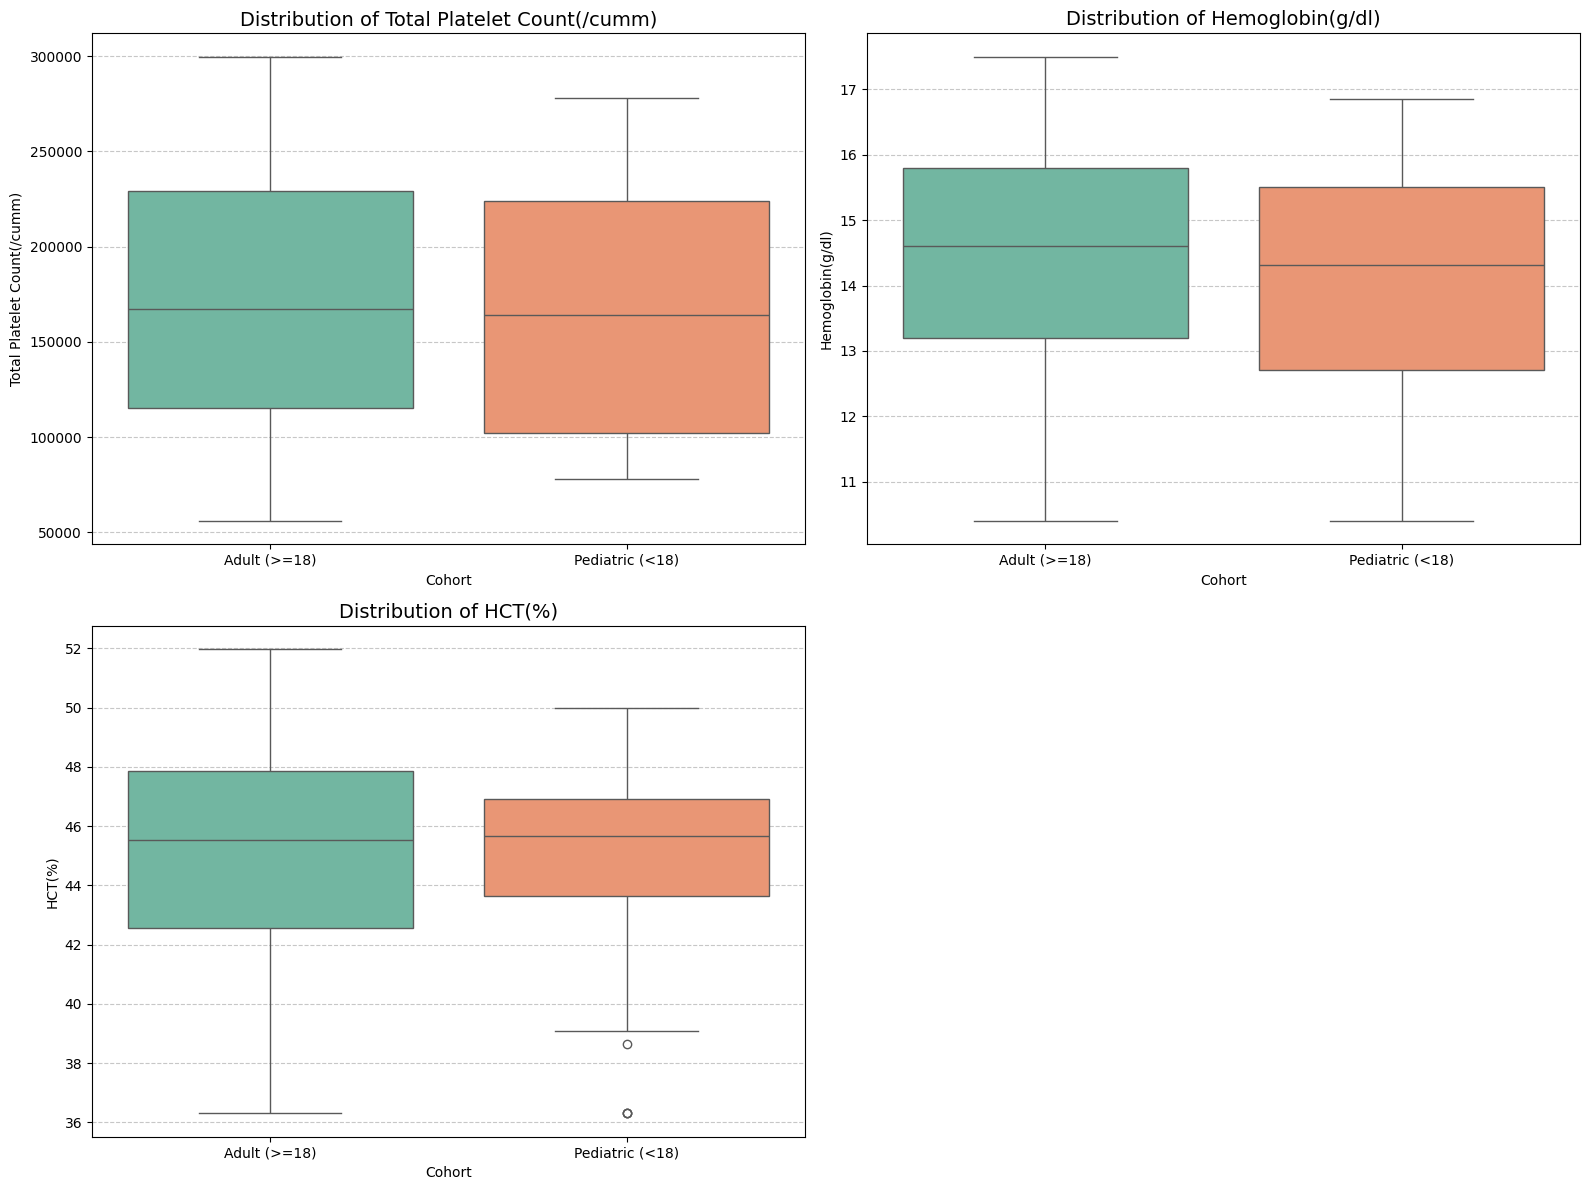

In [9]:
if len(eda_features) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()
    for i, col in enumerate(eda_features):
        sns.boxplot(x='Cohort', y=col, data=df_plot, ax=axes[i], palette='Set2', hue='Cohort', legend=False)
        axes[i].set_title(f'Distribution of {col}', fontsize=14)
        axes[i].grid(axis='y', linestyle='--', alpha=0.7)
        
    # Hide any unused axes
    for j in range(len(eda_features), len(axes)):
        fig.delaxes(axes[j])
        
    plt.tight_layout()
    plt.savefig('pediatric_vs_adult_eda.png')
    print("EDA plot saved as pediatric_vs_adult_eda.png")

In [10]:
# 3. Splitting
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
# 4. Model Training
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [12]:
# 5. Evaluation
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)

In [13]:
print("\n--- Model Performance (Training Set) ---")
print(f"Accuracy:  {accuracy_score(y_train, y_train_pred):.4f}")
print(f"Precision: {precision_score(y_train, y_train_pred, average='weighted'):.4f}")
print(f"Recall:    {recall_score(y_train, y_train_pred, average='weighted'):.4f}")
print(f"F1-Score:  {f1_score(y_train, y_train_pred, average='weighted'):.4f}")


--- Model Performance (Training Set) ---
Accuracy:  0.9975
Precision: 0.9975
Recall:    0.9975
F1-Score:  0.9975


In [14]:
print("\n--- Model Performance (Testing Set) ---")
print(f"Accuracy:  {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_test_pred, average='weighted'):.4f}")
print(f"Recall:    {recall_score(y_test, y_test_pred, average='weighted'):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_test_pred, average='weighted'):.4f}")


--- Model Performance (Testing Set) ---
Accuracy:  0.7082
Precision: 0.6825
Recall:    0.7082
F1-Score:  0.6850


In [15]:
joblib.dump(rf_model, 'dengue_rf_model.joblib')

['dengue_rf_model.joblib']

6 & 7. Age-Stratification and SHAP Analysis

In [16]:
explainer = shap.TreeExplainer(rf_model)

In [17]:
def generate_shap_plots(X_data, dataset_name):
    shap_values = explainer.shap_values(X_data, check_additivity=False)
    if isinstance(shap_values, list):
        sv_class1 = shap_values[1]
    else:
        sv_class1 = shap_values[:, :, 1] if len(shap_values.shape) == 3 else shap_values

    ped_mask = (X_data['Age'] < 18).values
    adult_mask = (X_data['Age'] >= 18).values

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 8))
    
    plt.sca(ax1)
    if sum(ped_mask) > 0:
        shap.summary_plot(sv_class1[ped_mask], X_data[ped_mask], show=False)
    ax1.set_title(f"Pediatric Cohort SHAP (n={sum(ped_mask)})", fontsize=16)

    plt.sca(ax2)
    if sum(adult_mask) > 0:
        shap.summary_plot(sv_class1[adult_mask], X_data[adult_mask], show=False)
    ax2.set_title(f"Adult Cohort SHAP (n={sum(adult_mask)})", fontsize=16)

    plt.tight_layout()
    filename = f'shap_comparison_{dataset_name}.png'
    plt.savefig(filename)
    print(f"SHAP plot saved as {filename}")


Generating SHAP for Test Dataset...


SHAP plot saved as shap_comparison_test_dataset.png


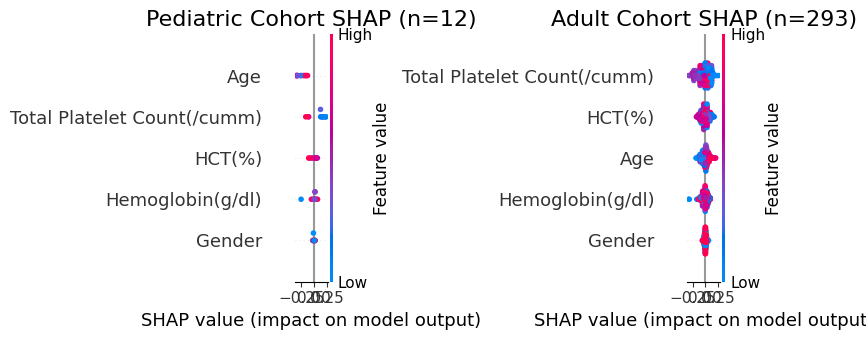

In [18]:
# Run for Test Dataset
print("\nGenerating SHAP for Test Dataset...")
generate_shap_plots(X_test, "test_dataset")


Generating SHAP for Whole Dataset...


SHAP plot saved as shap_comparison_full_dataset.png


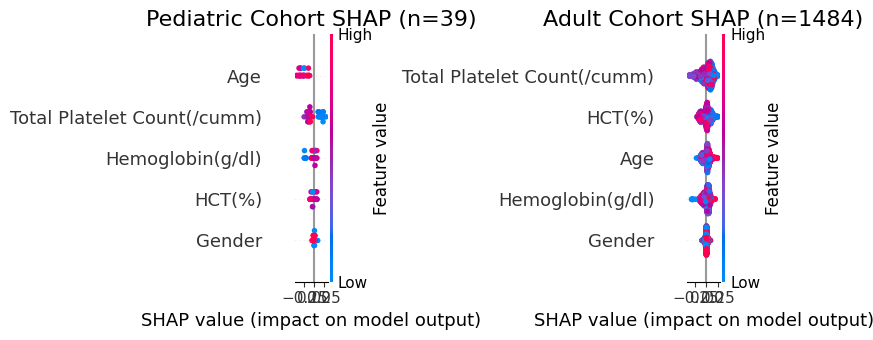

In [19]:
# Run for Whole Dataset
print("\nGenerating SHAP for Whole Dataset...")
generate_shap_plots(X, "full_dataset")

In [20]:
print("\nPipeline Execution Complete!")


Pipeline Execution Complete!
